# Part 1: DBNet Fine-Tuning on Manual Annotations + Detection Evaluation

**Goal:** Achieve ≥90% F1 word detection on real handwritten Hindi pages.

**Strategy:**
1. Load Session 1 CHIPS-pretrained DBNet checkpoint (`dbnet_best.pt`)
2. Fine-tune **exclusively** on 400 manually annotated real pages (NO CHIPS mixing)
3. Use heavy augmentation to prevent overfitting (only 320 training pages)
4. Validate detection quality with F1/Precision/Recall at IoU≥0.5
5. Save all artifacts for Part 2

**Critical design decisions:**
- ❌ NO CHIPS data during fine-tuning (mixing destroyed the model previously)
- ❌ NO threshold 0.1 anywhere
- ✅ Lower LR (5e-5) to preserve the CHIPS backbone
- ✅ Heavy augmentation (elastic, perspective, noise, blur, brightness)
- ✅ 5× oversampling of training pages
- ✅ Visual debug showing GT vs predicted boxes

**Time budget:** ~1-2 hours on Kaggle T4

**Required Kaggle inputs:**
- `phase4-dbnet-ckpt` → Session 1 checkpoint (`dbnet_best.pt`)
- `phase4-manual-annot` → Your annotated pages (`images/` + `labels.json`)
- `phase-3-5-model` → Phase 3.5 TrOCR checkpoint
- `hindi-page-level-dataset` → Real page parquets
- `hindi-htr-phase2-artifacts-improved` → `char_vocab.json`

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0: Install Dependencies
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q "python-doctr[torch]>=1.0" "transformers>=4.40,<5.0" \
    "peft>=0.10" "accelerate>=0.30" "albumentations==1.3.1" \
    "editdistance>=0.6" "pillow>=9.0" "opencv-python-headless>=4.8" \
    "matplotlib>=3.7" "numpy>=1.24" "pandas>=1.5" "scipy>=1.10"

import importlib
for _p in ["doctr", "cv2", "PIL", "numpy", "scipy", "peft"]:
    _m = importlib.import_module(_p)
    print(f"  {_p}: {getattr(_m, '__version__', 'ok')}")
print("All packages ready.")

  doctr: v1.0.1
  cv2: 4.13.0
  PIL: 11.3.0
  numpy: 2.4.6
  scipy: 1.16.3
  peft: 0.18.1
All packages ready.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1: Imports & Configuration
# ══════════════════════════════════════════════════════════════════════════════
import os, json, time, random, unicodedata, warnings, shutil, hashlib
from pathlib import Path
from io import BytesIO
from collections import Counter
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image
import scipy.ndimage as ndi
import torch, torch.nn as nn, torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import editdistance, albumentations as A
from transformers import VisionEncoderDecoderModel, TrOCRProcessor, get_scheduler
from peft import LoraConfig, get_peft_model, TaskType
os.environ["USE_TORCH"] = "1"
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}  VRAM: {p.total_mem/1e9:.1f}GB" if hasattr(p,'total_mem') else f"GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f}GB")

# ── Paths ─────────────────────────────────────────────────────────────────────
# IMPORTANT: Adjust these to match YOUR Kaggle dataset mount paths
DBNET_S1_CKPT    = Path("/kaggle/input/models/nehamalik10/phase-4-dbnet/pytorch/default/1/dbnet_best.pt")
MANUAL_ANNOT_DIR = Path("/kaggle/input/datasets/nehamalik10/phase4-manual-annot/annotated_data")
TROCR_CKPT       = Path("/kaggle/input/models/nehamalik10/phase-3-5-model/pytorch/default/1/best_model_trocr_final.pt")
PHASE2_DIR       = Path("/kaggle/input/datasets/nehamalik10/hindi-htr-phase2-artifacts-improved")
DATA_DIR         = Path("/kaggle/input/datasets/nehamalik10/hindi-page-level-dataset")

OUTPUT_DIR   = Path("/kaggle/working/phase4")
DBNET_DIR    = OUTPUT_DIR / "dbnet_ckpt"
CKPT_DIR     = OUTPUT_DIR / "checkpoints"
CROPS_DIR    = OUTPUT_DIR / "word_crops"
PSEUDO_DIR   = OUTPUT_DIR / "pseudo_labels"
RESULTS_DIR  = OUTPUT_DIR / "results"
MANUAL_DOCTR = OUTPUT_DIR / "manual_doctr"
for d in [OUTPUT_DIR, DBNET_DIR, CKPT_DIR, CROPS_DIR, PSEUDO_DIR, RESULTS_DIR, MANUAL_DOCTR]:
    d.mkdir(parents=True, exist_ok=True)

# ── DBNet Fine-Tuning Config (REAL PAGES ONLY) ────────────────────────────────
DET_IMG_SIZE   = 1024
DET_BS         = 2      # was 4
DET_LR         = 5e-5     # LOW LR — preserve CHIPS backbone, don't destroy it
DET_WD         = 5e-4
DET_EPOCHS     = 15        # With early stopping
DET_PATIENCE   = 5        # Stop if no improvement for 3 epochs
MANUAL_OVERSAMPLE = 8     # Oversample 320 train pages → 1600 effective/epoch
BEST_DET_CKPT = DBNET_DIR / "dbnet_manual_best.pt"
LAST_DET_CKPT = DBNET_DIR / "dbnet_manual_last.pt"

# ── Detection Inference Config (Post-Training) ────────────────────────────────
BIN_THRESH     = 0.05
BOX_THRESH     = 0.30
CONF_THRESH    = 0.05
MIN_WORD_H     = 8
MIN_WORD_W     = 6
IOU_MERGE_THRESH = 0.3
CROP_PAD       = 4

# ── TrOCR Config (saved for Part 2) ──────────────────────────────────────────
TROCR_SIZE     = 384
MAX_LEN        = 32
NO_REPEAT_NGRAM= 0
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05
LORA_TARGET    = ["q_proj", "k_proj", "v_proj", "out_proj"]

# ── NW Alignment Config ──────────────────────────────────────────────────────
MAX_EDIT_RATIO = 0.35
NW_GAP         = -1
NW_MATCH       = 2
NW_MISMATCH    = -1

# ── TrOCR Fine-Tune Config ───────────────────────────────────────────────────
FT_EPOCHS      = 6
FT_BS          = 8
FT_LR          = 2e-4
FT_WD          = 1e-4
FT_GRAD_CLIP   = 1.0
FT_PATIENCE    = 3
BEST_FT_PATH   = CKPT_DIR / "trocr_finetuned_phase4.pt"

print("Config ready.")

Device: cuda
GPU: Tesla T4  VRAM: 15.6GB
Config ready.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2: Load Vocabulary & Data
# ══════════════════════════════════════════════════════════════════════════════

# ── Devanagari Vocabulary ────────────────────────────────────────────────────
with open(PHASE2_DIR / "char_vocab.json", "r", encoding="utf-8") as f:
    _vocab = json.load(f)
if "char_to_idx" not in _vocab:
    raise KeyError(f"Expected 'char_to_idx', got: {list(_vocab.keys())}")
_c2i = _vocab["char_to_idx"]
actual_chars = sorted(
    [c for c in _c2i if c not in {"<BLANK>", "<UNK>", "<PAD>"}],
    key=lambda c: _c2i[c]
)
PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
char_to_token = {ch: i + 4 for i, ch in enumerate(actual_chars)}
token_to_char = {v: k for k, v in char_to_token.items()}
VOCAB_SIZE = 4 + len(actual_chars)

def encode(text):
    t = unicodedata.normalize("NFC", text)
    return [char_to_token.get(c, UNK_ID) for c in t]

def decode_ids(ids):
    out = []
    for tok in ids:
        tok = int(tok)
        if tok == EOS_ID:
            break
        if tok in (PAD_ID, BOS_ID):
            continue
        out.append(token_to_char.get(tok, ""))
    return unicodedata.normalize("NFC", "".join(out))

print(f"Vocab: {VOCAB_SIZE} tokens ({len(actual_chars)} chars)")

# ── Load Real Page Data ──────────────────────────────────────────────────────
def _detect_cols(df):
    cols = [c.lower() for c in df.columns]
    ic = next((df.columns[i] for i, c in enumerate(cols)
               if any(k in c for k in ("image", "img", "pixel"))), df.columns[0])
    tc = next((df.columns[i] for i, c in enumerate(cols)
               if any(k in c for k in ("text", "transcript", "label"))), df.columns[-1])
    return ic, tc

_corrupt = 0
def pil_page(page):
    global _corrupt
    if page["image_bytes"] is None:
        return Image.new("RGB", (512, 512), 255)
    try:
        return Image.open(BytesIO(page["image_bytes"])).convert("RGB")
    except:
        _corrupt += 1
        if _corrupt <= 3:
            print(f"  Corrupt image #{_corrupt}")
        return Image.new("RGB", (512, 512), 255)

def load_pages(parquet_path):
    df = pd.read_parquet(parquet_path)
    ic, tc = _detect_cols(df)
    pages = []
    for _, row in df.iterrows():
        img_data = row[ic]
        if isinstance(img_data, dict):
            img_bytes = img_data.get("bytes", None)
        else:
            img_bytes = img_data
        text = str(row[tc]) if pd.notna(row[tc]) else ""
        pages.append({"image_bytes": img_bytes, "text": text.strip()})
    return pages

train_pages = load_pages(DATA_DIR / "line_train.parquet")
val_pages   = load_pages(DATA_DIR / "line_val.parquet")
test_pages  = load_pages(DATA_DIR / "line_test.parquet")
print(f"Pages: train={len(train_pages):,}  val={len(val_pages):,}  test={len(test_pages):,}")

Vocab: 140 tokens (136 chars)
Pages: train=3,040  val=380  test=380


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: Preprocessing Utilities
# ══════════════════════════════════════════════════════════════════════════════

def autocontrast(gray, clip=1.0):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    total = float(gray.size)
    c = clip / 100 * total
    cs = np.cumsum(hist)
    lo = int(np.searchsorted(cs, c))
    hi = int(255 - np.searchsorted(cs[::-1], c))
    if hi <= lo:
        return gray
    return np.clip((gray.astype(np.float32) - lo) * 255 / (hi - lo), 0, 255).astype(np.uint8)

def deskew(gray, max_deg=5.0):
    lines = cv2.HoughLines(cv2.Canny(gray, 50, 150), 1, np.pi / 180, 100)
    if lines is None:
        return gray
    angle = float(np.median([l[0][1] * 180 / np.pi - 90 for l in lines]))
    if abs(angle) > max_deg:
        return gray
    h, w = gray.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(gray, M, (w, h), borderValue=255)

def preprocess_page(img):
    """Full page preprocessing: RGB → gray → autocontrast → deskew → back to RGB."""
    arr = np.array(img)
    if arr.ndim == 3 and arr.shape[2] == 4:
        arr = arr[:, :, :3]
    if arr.ndim == 2:
        gray = arr
    else:
        gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    gray = autocontrast(gray)
    gray = deskew(gray)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

# ── TrOCR crop preprocessing (FIXED) ─────────────────────────────────────────
_trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-small-handwritten")

def preprocess_crop_for_trocr(crop_pil):
    """Resize crop to 384×384 preserving aspect ratio on white canvas, then normalize."""
    w, h = crop_pil.size
    scale = min(TROCR_SIZE / w, TROCR_SIZE / h)
    nw, nh = int(w * scale), int(h * scale)
    resized = crop_pil.resize((nw, nh), Image.LANCZOS)
    canvas = Image.new("RGB", (TROCR_SIZE, TROCR_SIZE), (255, 255, 255))
    canvas.paste(resized, ((TROCR_SIZE - nw) // 2, (TROCR_SIZE - nh) // 2))
    pv = _trocr_processor(images=canvas, return_tensors="pt").pixel_values.squeeze(0)
    return pv

print("Preprocessing ready.")

special_tokens_map.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Preprocessing ready.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4: Load & Split Manual Annotations
# ══════════════════════════════════════════════════════════════════════════════

def load_manual_annotations(annot_dir, out_dir):
    """Load manual annotations, handling both doctr and COCO formats."""
    (out_dir / "images").mkdir(parents=True, exist_ok=True)
    
    labels_json = annot_dir / "labels.json"
    coco_json   = annot_dir / "annotations.json"
    img_dir     = annot_dir / "images"
    if not img_dir.exists():
        img_dir = annot_dir
    
    if labels_json.exists():
        print("  Found labels.json (doctr format)")
        with open(labels_json, encoding="utf-8") as f:
            labels = json.load(f)
        out_labels = {}
        copied = 0
        for fname, data in labels.items():
            src = img_dir / fname
            if not src.exists():
                src = annot_dir / fname
            if not src.exists():
                continue
            dst = out_dir / "images" / fname
            if not dst.exists():
                shutil.copy2(src, dst)
            out_labels[fname] = data
            copied += 1
        with open(out_dir / "labels.json", "w") as f:
            json.dump(out_labels, f)
        n_boxes = sum(len(v.get("polygons", [])) for v in out_labels.values())
        print(f"  Loaded: {copied} images, {n_boxes:,} boxes")
        return copied
    
    elif coco_json.exists():
        print("  Found annotations.json (COCO format)")
        with open(coco_json, encoding="utf-8") as f:
            coco = json.load(f)
        ann_map = {}
        for a in coco.get("annotations", []):
            ann_map.setdefault(a["image_id"], []).append(a)
        out_labels = {}
        copied = 0
        for img_info in coco.get("images", []):
            src = img_dir / img_info["file_name"]
            if not src.exists():
                continue
            dst = out_dir / "images" / img_info["file_name"]
            if not dst.exists():
                shutil.copy2(src, dst)
            W, H = img_info.get("width", 10000), img_info.get("height", 10000)
            polys = []
            for a in ann_map.get(img_info["id"], []):
                x, y, w, h = a["bbox"]
                x1, y1 = max(0, int(x)), max(0, int(y))
                x2, y2 = min(W, int(x + w)), min(H, int(y + h))
                if x2 > x1 and y2 > y1:
                    polys.append([[x1, y1], [x2, y1], [x2, y2], [x1, y2]])
            if polys:
                out_labels[img_info["file_name"]] = {"polygons": polys}
            copied += 1
        with open(out_dir / "labels.json", "w") as f:
            json.dump(out_labels, f)
        n_boxes = sum(len(v["polygons"]) for v in out_labels.values())
        print(f"  Loaded: {copied} images, {n_boxes:,} boxes")
        return copied
    else:
        raise FileNotFoundError(f"No labels.json or annotations.json in {annot_dir}")

_manual_count = load_manual_annotations(MANUAL_ANNOT_DIR, MANUAL_DOCTR)
print(f"Manual annotations loaded: {_manual_count} pages")

# ── Split into train (80%) / val (20%) ────────────────────────────────────────
with open(MANUAL_DOCTR / "labels.json", encoding="utf-8") as f:
    all_manual_labels = json.load(f)

manual_files = sorted(all_manual_labels.keys())
random.seed(42)
random.shuffle(manual_files)
n_val = max(10, len(manual_files) // 5)  # 20% for val
manual_val_files  = set(manual_files[:n_val])
manual_train_files = set(manual_files[n_val:])

MANUAL_TRAIN = OUTPUT_DIR / "manual_train"
MANUAL_VAL   = OUTPUT_DIR / "manual_val"
for d in [MANUAL_TRAIN, MANUAL_VAL]:
    (d / "images").mkdir(parents=True, exist_ok=True)

train_labels = {}
for f in manual_train_files:
    src = MANUAL_DOCTR / "images" / f
    if src.exists():
        shutil.copy2(src, MANUAL_TRAIN / "images" / f)
        train_labels[f] = all_manual_labels[f]
with open(MANUAL_TRAIN / "labels.json", "w") as fout:
    json.dump(train_labels, fout)

val_labels = {}
for f in manual_val_files:
    src = MANUAL_DOCTR / "images" / f
    if src.exists():
        shutil.copy2(src, MANUAL_VAL / "images" / f)
        val_labels[f] = all_manual_labels[f]
with open(MANUAL_VAL / "labels.json", "w") as fout:
    json.dump(val_labels, fout)

print(f"\nTrain: {len(train_labels)} pages, "
      f"{sum(len(v['polygons']) for v in train_labels.values()):,} boxes")
print(f"Val:   {len(val_labels)} pages, "
      f"{sum(len(v['polygons']) for v in val_labels.values()):,} boxes")

  Found labels.json (doctr format)
  Loaded: 409 images, 19,081 boxes
Manual annotations loaded: 409 pages

Train: 328 pages, 15,307 boxes
Val:   81 pages, 3,774 boxes


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: Custom Detection Dataset - aspect-ratio safe, inference-matched
# ══════════════════════════════════════════════════════════════════════════════

class AugmentedDetectionDataset(Dataset):
    """
    Produces:
      image_tensor: (3, DET_IMG_SIZE, DET_IMG_SIZE), float32 in [0, 1]
      target: {"words": np.ndarray (N, 5)}
              [xmin, ymin, xmax, ymax, flag] in relative padded-image coords
    """

    def __init__(self, img_dir, labels_path, img_size=1024, augment=False):
        self.img_dir = Path(img_dir)
        self.img_size = img_size
        self.augment = augment

        with open(labels_path, encoding="utf-8") as f:
            self.labels = json.load(f)

        self.filenames = [
            f for f in sorted(self.labels.keys())
            if (self.img_dir / f).exists()
        ]

    def __len__(self):
        return len(self.filenames)

    def _mild_augment(self, img, bboxes):
        if len(bboxes) == 0:
            return img, bboxes

        aug = A.Compose([
            A.Affine(
                scale=(0.97, 1.03),
                translate_percent=(-0.01, 0.01),
                rotate=(-1.0, 1.0),
                shear=(-0.5, 0.5),
                mode=cv2.BORDER_CONSTANT,
                cval=(255, 255, 255),
                p=0.35,
            ),
            A.OneOf([
                A.GaussNoise(var_limit=(3, 12), p=0.5),
                A.GaussianBlur(blur_limit=(3, 3), p=0.25),
            ], p=0.20),
            A.RandomBrightnessContrast(
                brightness_limit=0.06,
                contrast_limit=0.08,
                p=0.30,
            ),
        ], bbox_params=A.BboxParams(
            format="pascal_voc",
            min_area=12,
            min_visibility=0.45,
            label_fields=["labels"],
        ))

        try:
            out = aug(image=img, bboxes=bboxes, labels=[0] * len(bboxes))
            return out["image"], list(out["bboxes"])
        except Exception:
            return img, bboxes

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = self.img_dir / fname

        img = cv2.imread(str(img_path))
        if img is None:
            img = np.ones((self.img_size, self.img_size, 3), dtype=np.uint8) * 255
            return self._to_tensor(img), {"words": np.zeros((0, 5), dtype=np.float32)}

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Simple square stretch – exactly matches CHIPS pre‑training
        scale_x = self.img_size / w
        scale_y = self.img_size / h
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

        bboxes = []
        for poly in self.labels[fname].get("polygons", []):
            xs = [p[0] for p in poly]
            ys = [p[1] for p in poly]
            x1 = max(0, min(xs)) * scale_x
            y1 = max(0, min(ys)) * scale_y
            x2 = min(w, max(xs)) * scale_x
            y2 = min(h, max(ys)) * scale_y
            if x2 > x1 + 1 and y2 > y1 + 1:
                bboxes.append([x1, y1, x2, y2])

        if self.augment:
            img, bboxes = self._mild_augment(img, bboxes)

        boxes = []
        for x1, y1, x2, y2 in bboxes:
            x1 = max(0.0, min(1.0, x1 / self.img_size))
            y1 = max(0.0, min(1.0, y1 / self.img_size))
            x2 = max(0.0, min(1.0, x2 / self.img_size))
            y2 = max(0.0, min(1.0, y2 / self.img_size))

            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2, 0.0])

        target = {
            "words": np.array(boxes, dtype=np.float32)
            if boxes else np.zeros((0, 5), dtype=np.float32)
        }

        return self._to_tensor(img), target

    def _to_tensor(self, img):
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        return torch.from_numpy(img)

    @staticmethod
    def collate_fn(batch):
        images = torch.stack([item[0] for item in batch])
        targets = [item[1] for item in batch]
        return images, targets


# Quick sanity check
_test_ds = AugmentedDetectionDataset(
    str(MANUAL_TRAIN / "images"),
    str(MANUAL_TRAIN / "labels.json"),
    img_size=DET_IMG_SIZE,
    augment=True,
)

_img, _tgt = _test_ds[0]
print(f"Test sample: img={_img.shape}, target={_tgt['words'].shape}")
print(f"Image range: [{_img.min():.3f}, {_img.max():.3f}]")
if len(_tgt["words"]) > 0:
    print("First box:", _tgt["words"][0])
print(f"Dataset ready: {len(_test_ds)} training images")

Test sample: img=torch.Size([3, 1024, 1024]), target=(37, 5)
Image range: [0.051, 0.973]
First box: [0.07291666 0.30343136 0.2985026  0.35514706 0.        ]
Dataset ready: 328 training images


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6: Load Session 1 DBNet + Build DataLoaders
# ══════════════════════════════════════════════════════════════════════════════

import gc
from doctr.models import db_resnet50

gc.collect()
torch.cuda.empty_cache()

# Make sure both checkpoint paths exist
BEST_DET_CKPT = DBNET_DIR / "dbnet_manual_best.pt"
LAST_DET_CKPT = DBNET_DIR / "dbnet_manual_last.pt"

# Load Session 1 DBNet
det_model = db_resnet50(pretrained=False)

state = torch.load(DBNET_S1_CKPT, map_location="cpu", weights_only=False)
if isinstance(state, dict) and "model" in state:
    state = state["model"]

det_model.load_state_dict(state)
det_model = det_model.to(DEVICE)

def freeze_batchnorm(module):
    if isinstance(module, (nn.BatchNorm2d, nn.SyncBatchNorm)):
        module.eval()
        for p in module.parameters():
            p.requires_grad = False

# Freeze BatchNorm only. Do NOT freeze ResNet backbone.
det_model.apply(freeze_batchnorm)

print(f"Session 1 DBNet loaded from: {DBNET_S1_CKPT}")
print("Frozen BatchNorm stats only; full DBNet weights can adapt.")

# Build datasets
train_ds = AugmentedDetectionDataset(
    str(MANUAL_TRAIN / "images"),
    str(MANUAL_TRAIN / "labels.json"),
    img_size=DET_IMG_SIZE,
    augment=True,
)

val_ds = AugmentedDetectionDataset(
    str(MANUAL_VAL / "images"),
    str(MANUAL_VAL / "labels.json"),
    img_size=DET_IMG_SIZE,
    augment=False,
)

oversampled_ds = ConcatDataset([train_ds] * MANUAL_OVERSAMPLE)

train_dl = DataLoader(
    oversampled_ds,
    batch_size=DET_BS,
    shuffle=True,
    collate_fn=AugmentedDetectionDataset.collate_fn,
    num_workers=2,
    pin_memory=True,
)

val_dl = DataLoader(
    val_ds,
    batch_size=DET_BS,
    shuffle=False,
    collate_fn=AugmentedDetectionDataset.collate_fn,
    num_workers=2,
    pin_memory=True,
)

print(f"Train: {len(train_ds)} pages x {MANUAL_OVERSAMPLE} = {len(oversampled_ds)} samples/epoch")
print(f"Val:   {len(val_ds)} pages")

Session 1 DBNet loaded from: /kaggle/input/models/nehamalik10/phase-4-dbnet/pytorch/default/1/dbnet_best.pt
Frozen BatchNorm stats only; full DBNet weights can adapt.
Train: 328 pages x 8 = 2624 samples/epoch
Val:   81 pages


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: Train DBNet on Manual Pages
# ══════════════════════════════════════════════════════════════════════════════

import gc
gc.collect()
torch.cuda.empty_cache()

def set_bn_eval(module):
    if isinstance(module, (nn.BatchNorm2d, nn.SyncBatchNorm)):
        module.eval()

trainable_params = [p for p in det_model.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable_params):,}")

optimizer = optim.AdamW(trainable_params, lr=DET_LR, weight_decay=DET_WD)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=2e-6,
)

scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
GRAD_ACCUM = 4

best_val_loss = float("inf")
patience_counter = 0
train_losses = []
val_losses = []

print(f"Stable fine-tuning DBNet: pages={len(train_ds)}, oversample={MANUAL_OVERSAMPLE}")
print(f"Epochs={DET_EPOCHS}, LR={DET_LR}, BS={DET_BS}, grad_accum={GRAD_ACCUM}")
print("=" * 70, flush=True)

for epoch in range(1, DET_EPOCHS + 1):
    t0 = time.time()

    # Train
    det_model.train()
    det_model.apply(set_bn_eval)

    ep_loss = 0.0
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (imgs, tgts) in enumerate(train_dl):
        imgs = imgs.to(DEVICE)

        with autocast("cuda", enabled=(DEVICE.type == "cuda")):
            out = det_model(
                imgs,
                target=tgts,
                return_model_output=False,
                return_preds=False,
            )
            loss = out["loss"] / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_dl):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(trainable_params, 2.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        ep_loss += loss.item() * GRAD_ACCUM
        n_batches += 1

    avg_train = ep_loss / max(n_batches, 1)
    train_losses.append(avg_train)

    # Validate
    det_model.eval()
    val_loss = 0.0
    n_val = 0

    with torch.no_grad():
        for imgs, tgts in val_dl:
            imgs = imgs.to(DEVICE)

            with autocast("cuda", enabled=(DEVICE.type == "cuda")):
                out = det_model(
                    imgs,
                    target=tgts,
                    return_model_output=False,
                    return_preds=False,
                )

            val_loss += out["loss"].item()
            n_val += 1

    avg_val = val_loss / max(n_val, 1)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    torch.save(det_model.state_dict(), LAST_DET_CKPT)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(det_model.state_dict(), BEST_DET_CKPT)
        patience_counter = 0
        marker = "  * saved best"
    else:
        patience_counter += 1
        marker = f"  patience {patience_counter}/{DET_PATIENCE}"

    print(
        f"EP {epoch:02d}/{DET_EPOCHS} "
        f"train_loss={avg_train:.4f} "
        f"val_loss={avg_val:.4f} "
        f"lr={optimizer.param_groups[0]['lr']:.2e} "
        f"t={time.time() - t0:.0f}s{marker}",
        flush=True,
    )

    if patience_counter >= DET_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"Done. Best val loss: {best_val_loss:.4f}")
print(f"Best checkpoint: {BEST_DET_CKPT}")
print(f"Last checkpoint: {LAST_DET_CKPT}")

Trainable params: 25,355,970
Stable fine-tuning DBNet: pages=328, oversample=8
Epochs=15, LR=5e-05, BS=2, grad_accum=4
EP 01/15 train_loss=0.7624 val_loss=0.4810 lr=5.00e-05 t=527s  * saved best
EP 02/15 train_loss=0.4560 val_loss=0.4404 lr=5.00e-05 t=520s  * saved best
EP 03/15 train_loss=0.4183 val_loss=0.4160 lr=5.00e-05 t=520s  * saved best
EP 04/15 train_loss=0.3955 val_loss=0.3918 lr=5.00e-05 t=522s  * saved best
EP 05/15 train_loss=0.3779 val_loss=0.3788 lr=5.00e-05 t=536s  * saved best
EP 06/15 train_loss=0.3618 val_loss=0.3648 lr=5.00e-05 t=575s  * saved best
EP 07/15 train_loss=0.3495 val_loss=0.3579 lr=5.00e-05 t=573s  * saved best
EP 08/15 train_loss=0.3388 val_loss=0.3455 lr=5.00e-05 t=564s  * saved best
EP 09/15 train_loss=0.3286 val_loss=0.3348 lr=5.00e-05 t=577s  * saved best
EP 10/15 train_loss=0.3202 val_loss=0.3292 lr=5.00e-05 t=580s  * saved best
EP 11/15 train_loss=0.3124 val_loss=0.3230 lr=5.00e-05 t=575s  * saved best
EP 12/15 train_loss=0.3069 val_loss=0.3196 lr

manual_best bin=0.300 box=0.100 gap= 0 P=0.735 R=0.780 F1=0.757 boxes=49.5
manual_best bin=0.300 box=0.100 gap= 8 P=0.673 R=0.661 F1=0.667 boxes=45.8
manual_best bin=0.300 box=0.100 gap=16 P=0.644 R=0.610 F1=0.626 boxes=44.1
manual_best bin=0.300 box=0.200 gap= 0 P=0.735 R=0.780 F1=0.757 boxes=49.5
manual_best bin=0.300 box=0.200 gap= 8 P=0.673 R=0.661 F1=0.667 boxes=45.8
manual_best bin=0.300 box=0.200 gap=16 P=0.644 R=0.610 F1=0.626 boxes=44.1
manual_best bin=0.300 box=0.300 gap= 0 P=0.738 R=0.780 F1=0.758 boxes=49.3
manual_best bin=0.300 box=0.300 gap= 8 P=0.675 R=0.661 F1=0.668 boxes=45.6
manual_best bin=0.300 box=0.300 gap=16 P=0.647 R=0.610 F1=0.628 boxes=43.9
manual_best bin=0.400 box=0.100 gap= 0 P=0.871 R=0.938 F1=0.903 boxes=50.2
manual_best bin=0.400 box=0.100 gap= 8 P=0.831 R=0.841 F1=0.836 boxes=47.1
manual_best bin=0.400 box=0.100 gap=16 P=0.786 R=0.750 F1=0.767 boxes=44.4
manual_best bin=0.400 box=0.200 gap= 0 P=0.871 R=0.938 F1=0.903 boxes=50.2
manual_best bin=0.400 box

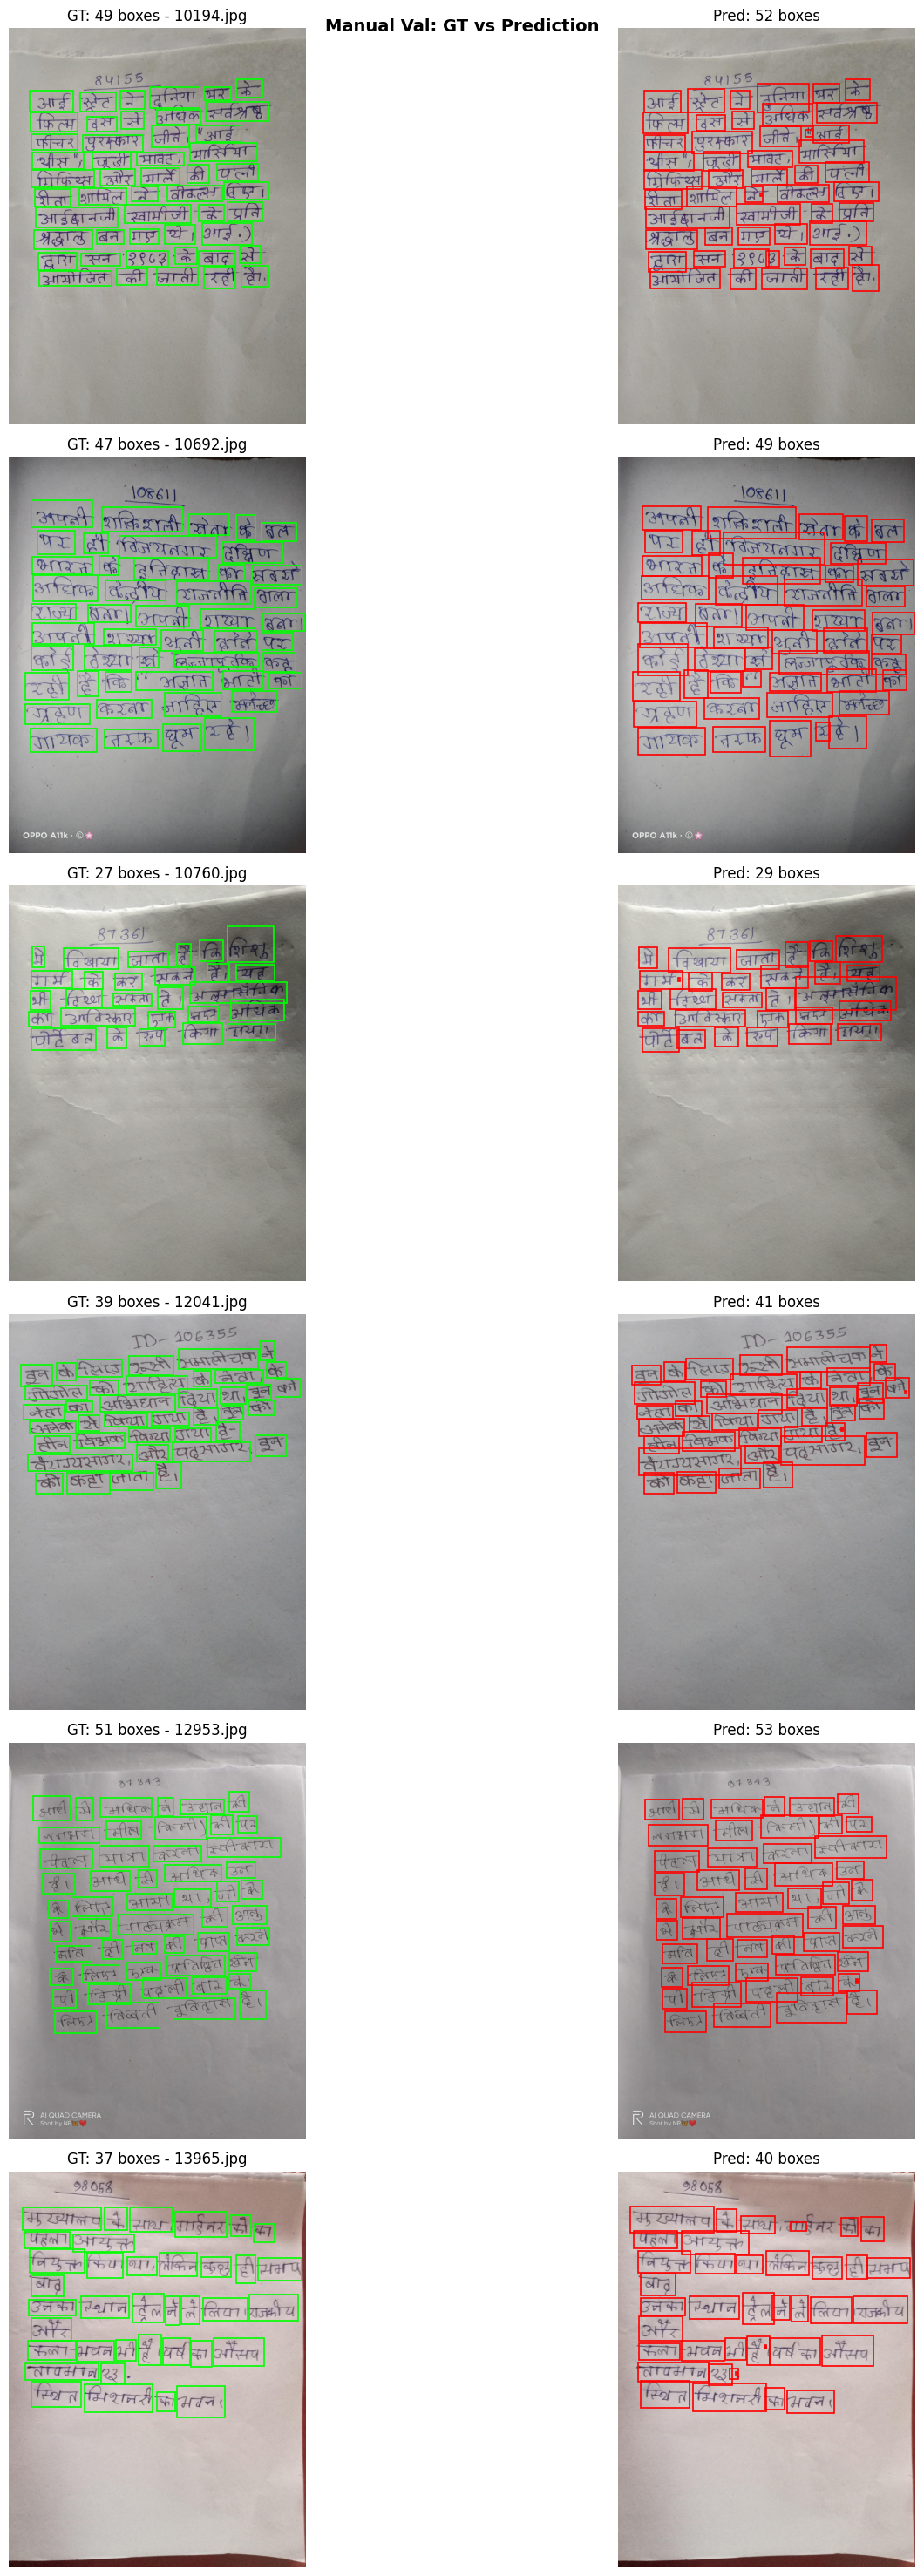

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: EVALUATION: Manual Val Detection + Correct Unpadding + Visualization
# ══════════════════════════════════════════════════════════════════════════════

from doctr.models.detection.predictor import DetectionPredictor
from doctr.models.preprocessor import PreProcessor

def _parse_det_output(raw):
    if isinstance(raw, dict):
        raw = raw.get("words", raw.get("boxes", np.zeros((0, 5), dtype=np.float32)))
    arr = np.asarray(raw)
    if arr.ndim == 2 and arr.shape[1] >= 5:
        return arr.astype(np.float32)
    return np.zeros((0, 5), dtype=np.float32)

def make_predictor(ckpt_path, bin_thresh=0.30, box_thresh=0.05):
    det = db_resnet50(pretrained=False)

    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    if isinstance(state, dict) and "model" in state:
        state = state["model"]

    det.load_state_dict(state)
    det.postprocessor.bin_thresh = bin_thresh
    det.postprocessor.box_thresh = box_thresh
    det = det.to(DEVICE).eval()

    pre = PreProcessor(
        (DET_IMG_SIZE, DET_IMG_SIZE),
        batch_size=1,
        mean=(0.0, 0.0, 0.0),          # no color normalisation
        std=(1.0, 1.0, 1.0),
        preserve_aspect_ratio=False,    # square‑stretch, exactly like training
    )

    return DetectionPredictor(pre_processor=pre, model=det)


def filter_tiny_boxes_px(boxes, min_w=4, min_h=4):
    keep = []
    for b in boxes:
        if (b[2] - b[0]) >= min_w and (b[3] - b[1]) >= min_h:
            keep.append(b)
    return np.array(keep, dtype=np.float32) if keep else np.zeros((0, 5), dtype=np.float32)

def merge_nearby_boxes_px(boxes, x_gap=16, y_overlap=0.30):
    if len(boxes) == 0:
        return boxes

    boxes = sorted(boxes.tolist(), key=lambda b: (b[1], b[0]))
    merged = []

    for b in boxes:
        placed = False

        for m in merged:
            gap = b[0] - m[2]
            overlap_y = max(0, min(m[3], b[3]) - max(m[1], b[1]))
            min_h = max(1, min(m[3] - m[1], b[3] - b[1]))

            if -5 <= gap <= x_gap and overlap_y / min_h >= y_overlap:
                m[0] = min(m[0], b[0])
                m[1] = min(m[1], b[1])
                m[2] = max(m[2], b[2])
                m[3] = max(m[3], b[3])
                m[4] = max(m[4], b[4])
                placed = True
                break

        if not placed:
            merged.append(b)

    return np.array(merged, dtype=np.float32)

def predict_boxes_px(predictor, img_rgb, merge_gap=16):
    h, w = img_rgb.shape[:2]
    raw = _parse_det_output(predictor([img_rgb])[0])

    boxes = []
    for b in raw:
        x1 = float(b[0]) * w          # relative → absolute pixel
        y1 = float(b[1]) * h
        x2 = float(b[2]) * w
        y2 = float(b[3]) * h
        conf = float(b[4])
        if x2 > x1 and y2 > y1:
            boxes.append([x1, y1, x2, y2, conf])

    boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 5), dtype=np.float32)
    boxes = filter_tiny_boxes_px(boxes, min_w=4, min_h=4)
    if merge_gap and merge_gap > 0:
        boxes = merge_nearby_boxes_px(boxes, x_gap=merge_gap, y_overlap=0.30)
    return boxes

def iou_xyxy(a, b):
    ix1 = max(a[0], b[0])
    iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2])
    iy2 = min(a[3], b[3])

    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = max(0, a[2] - a[0]) * max(0, a[3] - a[1])
    area_b = max(0, b[2] - b[0]) * max(0, b[3] - b[1])
    union = area_a + area_b - inter

    return inter / union if union > 0 else 0.0

def eval_detection(predictor, labels_path, img_dir, merge_gap=16, iou_thresh=0.5):
    with open(labels_path, encoding="utf-8") as f:
        labels = json.load(f)

    total_tp, total_fp, total_fn = 0, 0, 0
    counts = []

    for fname, data in labels.items():
        img_path = Path(img_dir) / fname
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pred = predict_boxes_px(predictor, img_rgb, merge_gap=merge_gap)
        counts.append(len(pred))

        gt_boxes = []
        for poly in data.get("polygons", []):
            xs = [p[0] for p in poly]
            ys = [p[1] for p in poly]
            gt_boxes.append([min(xs), min(ys), max(xs), max(ys)])

        matched_gt = set()

        if len(pred) > 0:
            for pi in np.argsort(-pred[:, 4]):
                best_iou = 0.0
                best_gi = -1

                for gi, gt in enumerate(gt_boxes):
                    if gi in matched_gt:
                        continue

                    score = iou_xyxy(pred[pi][:4], gt)
                    if score > best_iou:
                        best_iou = score
                        best_gi = gi

                if best_iou >= iou_thresh:
                    total_tp += 1
                    matched_gt.add(best_gi)
                else:
                    total_fp += 1

        total_fn += len(gt_boxes) - len(matched_gt)

    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "mean_boxes": float(np.mean(counts)) if counts else 0.0,
    }

# Search thresholds
ckpts = []
if BEST_DET_CKPT.exists():
    ckpts.append(("manual_best", BEST_DET_CKPT))
# if LAST_DET_CKPT.exists():
#     ckpts.append(("manual_last", LAST_DET_CKPT))

best = None

for name, ckpt in ckpts:
    for bt in [0.30, 0.40, 0.50]:
        for bx in [0.10, 0.20, 0.30]:
            predictor = make_predictor(ckpt, bin_thresh=bt, box_thresh=bx)

            for gap in [0, 8, 16]:
                m = eval_detection(
                    predictor,
                    MANUAL_VAL / "labels.json",
                    MANUAL_VAL / "images",
                    merge_gap=gap,
                    iou_thresh=0.5,
                )

                row = (m["f1"], name, ckpt, bt, bx, gap, m)
                if best is None or row[0] > best[0]:
                    best = row

                print(
                    f"{name:11s} bin={bt:.3f} box={bx:.3f} gap={gap:2d} "
                    f"P={m['precision']:.3f} R={m['recall']:.3f} "
                    f"F1={m['f1']:.3f} boxes={m['mean_boxes']:.1f}"
                )

best_f1, best_name, best_ckpt, best_bin, best_box, best_gap, det_metrics = best
DET_PREDICTOR = make_predictor(best_ckpt, best_bin, best_box)

print("\nBEST:")
print(f"checkpoint={best_name} {best_ckpt}")
print(f"bin={best_bin}, box={best_box}, merge_gap={best_gap}")
print(det_metrics)

# Visualization
with open(MANUAL_VAL / "labels.json", encoding="utf-8") as f:
    val_labels = json.load(f)

show_files = sorted(val_labels.keys())[:6]

fig, axes = plt.subplots(len(show_files), 2, figsize=(18, 5 * len(show_files)))
if len(show_files) == 1:
    axes = axes.reshape(1, -1)

for row, fname in enumerate(show_files):
    img_path = MANUAL_VAL / "images" / fname
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt_polys = val_labels[fname].get("polygons", [])

    axes[row, 0].imshow(img_rgb)
    for poly in gt_polys:
        xs = [p[0] for p in poly]
        ys = [p[1] for p in poly]
        x1, y1 = min(xs), min(ys)
        x2, y2 = max(xs), max(ys)
        axes[row, 0].add_patch(
            plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=1.2,
                edgecolor="lime",
                facecolor="none",
            )
        )
    axes[row, 0].set_title(f"GT: {len(gt_polys)} boxes - {fname}")
    axes[row, 0].axis("off")

    pred = predict_boxes_px(DET_PREDICTOR, img_rgb, merge_gap=best_gap)

    axes[row, 1].imshow(img_rgb)
    for b in pred:
        axes[row, 1].add_patch(
            plt.Rectangle(
                (b[0], b[1]),
                b[2] - b[0],
                b[3] - b[1],
                linewidth=1.2,
                edgecolor="red",
                facecolor="none",
            )
        )
    axes[row, 1].set_title(f"Pred: {len(pred)} boxes")
    axes[row, 1].axis("off")

plt.suptitle("Manual Val: GT vs Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "detection_debug_fixed.png", dpi=140, bbox_inches="tight")
plt.show()

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# RESUME TRAINING – Continue fine‑tuning from current best checkpoint
# ══════════════════════════════════════════════════════════════════════════════

import gc

gc.collect()
torch.cuda.empty_cache()

# 1 – Load the best model we already have
det_model.load_state_dict(torch.load(BEST_DET_CKPT, map_location="cpu"))
det_model = det_model.to(DEVICE)
det_model.apply(freeze_batchnorm)          # keep BN frozen

# 2 – Re‑create optimizer & scheduler (fresh state, same hyper‑params)
trainable_params = [p for p in det_model.parameters() if p.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=DET_LR, weight_decay=DET_WD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=2e-6
)
scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

# 3 – Keep the previous best val loss so early‑stopping continues correctly
best_val_loss = 0.3042        # ← your previous best
patience_counter = 0

ADDITIONAL_EPOCHS = 8

print(f"Resume fine‑tuning: {ADDITIONAL_EPOCHS} epochs, LR={DET_LR}, oversample={MANUAL_OVERSAMPLE}")
print("=" * 70, flush=True)

for epoch in range(1, ADDITIONAL_EPOCHS + 1):
    t0 = time.time()

    # ── Train ───────────────────────────────────────────────────────────────
    det_model.train()
    det_model.apply(set_bn_eval)

    ep_loss = 0.0
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (imgs, tgts) in enumerate(train_dl):
        imgs = imgs.to(DEVICE)

        with autocast("cuda", enabled=(DEVICE.type == "cuda")):
            out = det_model(imgs, target=tgts, return_model_output=False, return_preds=False)
            loss = out["loss"] / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_dl):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(trainable_params, 2.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        ep_loss += loss.item() * GRAD_ACCUM
        n_batches += 1

    avg_train = ep_loss / max(n_batches, 1)
    train_losses.append(avg_train)

    # ── Validate ────────────────────────────────────────────────────────────
    det_model.eval()
    val_loss = 0.0
    n_val = 0

    with torch.no_grad():
        for imgs, tgts in val_dl:
            imgs = imgs.to(DEVICE)
            with autocast("cuda", enabled=(DEVICE.type == "cuda")):
                out = det_model(imgs, target=tgts, return_model_output=False, return_preds=False)
            val_loss += out["loss"].item()
            n_val += 1

    avg_val = val_loss / max(n_val, 1)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    torch.save(det_model.state_dict(), LAST_DET_CKPT)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(det_model.state_dict(), BEST_DET_CKPT)
        patience_counter = 0
        marker = "  * saved best"
    else:
        patience_counter += 1
        marker = f"  patience {patience_counter}/{DET_PATIENCE}"

    print(
        f"EP {epoch:02d}/{ADDITIONAL_EPOCHS} "
        f"train_loss={avg_train:.4f} "
        f"val_loss={avg_val:.4f} "
        f"lr={optimizer.param_groups[0]['lr']:.2e} "
        f"t={time.time() - t0:.0f}s{marker}",
        flush=True,
    )

    if patience_counter >= DET_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"Resumed training done. Best val loss: {best_val_loss:.4f}")

Resume fine‑tuning: 8 epochs, LR=5e-05, oversample=8
EP 01/8 train_loss=0.2881 val_loss=0.3023 lr=5.00e-05 t=578s  * saved best
EP 02/8 train_loss=0.2847 val_loss=0.2981 lr=5.00e-05 t=588s  * saved best
EP 03/8 train_loss=0.2814 val_loss=0.2948 lr=5.00e-05 t=594s  * saved best
EP 04/8 train_loss=0.2783 val_loss=0.2939 lr=5.00e-05 t=595s  * saved best
EP 05/8 train_loss=0.2756 val_loss=0.2907 lr=5.00e-05 t=599s  * saved best
EP 06/8 train_loss=0.2724 val_loss=0.2890 lr=5.00e-05 t=603s  * saved best
EP 07/8 train_loss=0.2707 val_loss=0.2855 lr=5.00e-05 t=603s  * saved best
EP 08/8 train_loss=0.2682 val_loss=0.2864 lr=5.00e-05 t=601s  patience 1/5
Resumed training done. Best val loss: 0.2855


fine manual_best bin=0.40 box=0.06 gap=0  P=0.897 R=0.940 F1=0.918 boxes=48.8
fine manual_best bin=0.40 box=0.08 gap=0  P=0.897 R=0.940 F1=0.918 boxes=48.8
fine manual_best bin=0.40 box=0.10 gap=0  P=0.897 R=0.940 F1=0.918 boxes=48.8
fine manual_best bin=0.40 box=0.12 gap=0  P=0.897 R=0.940 F1=0.918 boxes=48.8
fine manual_best bin=0.40 box=0.14 gap=0  P=0.897 R=0.940 F1=0.918 boxes=48.8
fine manual_best bin=0.45 box=0.06 gap=0  P=0.919 R=0.962 F1=0.940 boxes=48.8
fine manual_best bin=0.45 box=0.08 gap=0  P=0.919 R=0.962 F1=0.940 boxes=48.8
fine manual_best bin=0.45 box=0.10 gap=0  P=0.919 R=0.962 F1=0.940 boxes=48.8
fine manual_best bin=0.45 box=0.12 gap=0  P=0.919 R=0.962 F1=0.940 boxes=48.8
fine manual_best bin=0.45 box=0.14 gap=0  P=0.919 R=0.962 F1=0.940 boxes=48.8
fine manual_best bin=0.48 box=0.06 gap=0  P=0.914 R=0.966 F1=0.939 boxes=49.3
fine manual_best bin=0.48 box=0.08 gap=0  P=0.914 R=0.966 F1=0.939 boxes=49.3
fine manual_best bin=0.48 box=0.10 gap=0  P=0.914 R=0.966 F1=0.9

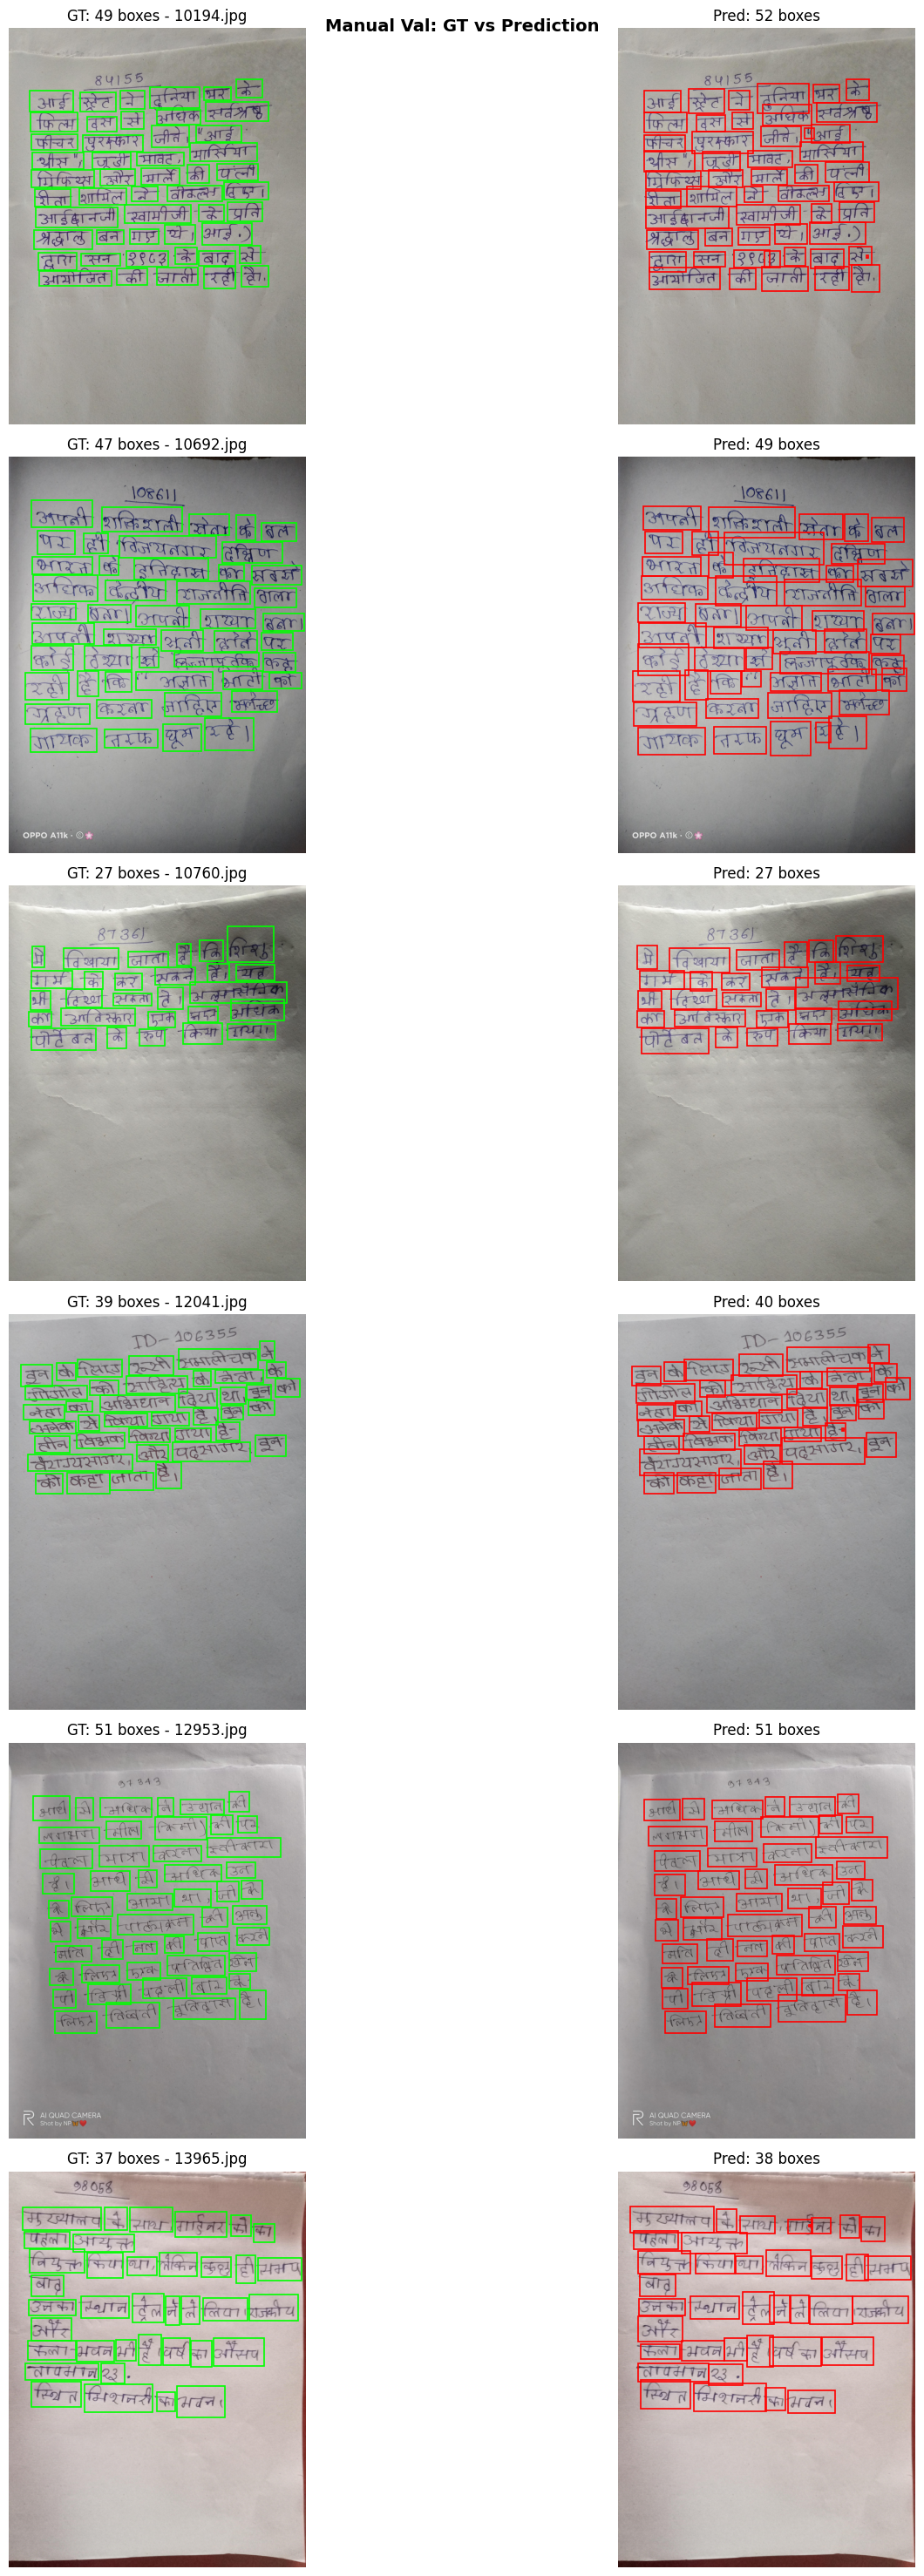

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: Detection Evaluation (Manual Val) + Threshold Sweep + Visualisation
# ══════════════════════════════════════════════════════════════════════════════

from doctr.models.detection.predictor import DetectionPredictor
from doctr.models.preprocessor import PreProcessor

# ── Helper: parse doctr detection output ──────────────────────────────────────
def _parse_det_output(raw):
    if isinstance(raw, dict):
        raw = raw.get("words", raw.get("boxes", np.zeros((0, 5), dtype=np.float32)))
    arr = np.asarray(raw)
    if arr.ndim == 2 and arr.shape[1] >= 5:
        return arr.astype(np.float32)
    return np.zeros((0, 5), dtype=np.float32)

# ── Build predictor with given thresholds ─────────────────────────────────────
def make_predictor(ckpt_path, bin_thresh=0.30, box_thresh=0.05):
    det = db_resnet50(pretrained=False)
    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    if isinstance(state, dict) and "model" in state:
        state = state["model"]
    det.load_state_dict(state)
    det.postprocessor.bin_thresh = bin_thresh
    det.postprocessor.box_thresh = box_thresh
    det = det.to(DEVICE).eval()

    pre = PreProcessor(
        (DET_IMG_SIZE, DET_IMG_SIZE),
        batch_size=1,
        mean=(0.0, 0.0, 0.0),          # no colour normalisation
        std=(1.0, 1.0, 1.0),
        preserve_aspect_ratio=False,    # square‑stretch, exactly like training
    )
    return DetectionPredictor(pre_processor=pre, model=det)

# ── Box filters ───────────────────────────────────────────────────────────────
def filter_tiny_boxes_px(boxes, min_w=4, min_h=4):
    keep = []
    for b in boxes:
        if (b[2] - b[0]) >= min_w and (b[3] - b[1]) >= min_h:
            keep.append(b)
    return np.array(keep, dtype=np.float32) if keep else np.zeros((0, 5), dtype=np.float32)

def merge_nearby_boxes_px(boxes, x_gap=16, y_overlap=0.30):
    if len(boxes) == 0:
        return boxes
    boxes = sorted(boxes.tolist(), key=lambda b: (b[1], b[0]))
    merged = []
    for b in boxes:
        placed = False
        for m in merged:
            gap = b[0] - m[2]
            overlap_y = max(0, min(m[3], b[3]) - max(m[1], b[1]))
            min_h = max(1, min(m[3] - m[1], b[3] - b[1]))
            if -5 <= gap <= x_gap and overlap_y / min_h >= y_overlap:
                m[0] = min(m[0], b[0])
                m[1] = min(m[1], b[1])
                m[2] = max(m[2], b[2])
                m[3] = max(m[3], b[3])
                m[4] = max(m[4], b[4])
                placed = True
                break
        if not placed:
            merged.append(b)
    return np.array(merged, dtype=np.float32)

# ── Prediction (relative → absolute pixel) ────────────────────────────────────
def predict_boxes_px(predictor, img_rgb, merge_gap=16):
    h, w = img_rgb.shape[:2]
    raw = _parse_det_output(predictor([img_rgb])[0])
    boxes = []
    for b in raw:
        x1 = float(b[0]) * w
        y1 = float(b[1]) * h
        x2 = float(b[2]) * w
        y2 = float(b[3]) * h
        conf = float(b[4])
        if x2 > x1 and y2 > y1:
            boxes.append([x1, y1, x2, y2, conf])
    boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 5), dtype=np.float32)
    boxes = filter_tiny_boxes_px(boxes, min_w=4, min_h=4)
    if merge_gap and merge_gap > 0:
        boxes = merge_nearby_boxes_px(boxes, x_gap=merge_gap, y_overlap=0.30)
    return boxes

# ── IoU ──────────────────────────────────────────────────────────────────────
def iou_xyxy(a, b):
    ix1 = max(a[0], b[0])
    iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2])
    iy2 = min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = max(0, a[2] - a[0]) * max(0, a[3] - a[1])
    area_b = max(0, b[2] - b[0]) * max(0, b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

# ── Detection evaluation on labelled images ───────────────────────────────────
def eval_detection(predictor, labels_path, img_dir, merge_gap=16, iou_thresh=0.5):
    with open(labels_path, encoding="utf-8") as f:
        labels = json.load(f)

    total_tp, total_fp, total_fn = 0, 0, 0
    counts = []

    for fname, data in labels.items():
        img_path = Path(img_dir) / fname
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pred = predict_boxes_px(predictor, img_rgb, merge_gap=merge_gap)
        counts.append(len(pred))

        gt_boxes = []
        for poly in data.get("polygons", []):
            xs = [p[0] for p in poly]
            ys = [p[1] for p in poly]
            gt_boxes.append([min(xs), min(ys), max(xs), max(ys)])

        matched_gt = set()
        if len(pred) > 0:
            for pi in np.argsort(-pred[:, 4]):
                best_iou = 0.0
                best_gi = -1
                for gi, gt in enumerate(gt_boxes):
                    if gi in matched_gt:
                        continue
                    score = iou_xyxy(pred[pi][:4], gt)
                    if score > best_iou:
                        best_iou = score
                        best_gi = gi
                if best_iou >= iou_thresh:
                    total_tp += 1
                    matched_gt.add(best_gi)
                else:
                    total_fp += 1

        total_fn += len(gt_boxes) - len(matched_gt)

    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "mean_boxes": float(np.mean(counts)) if counts else 0.0,
    }

# ═══════════════════════════════════════════════════════════════════════════════
# ── Sweep thresholds and find best configuration ──────────────────────────────
# ═══════════════════════════════════════════════════════════════════════════════

ckpts = []
if BEST_DET_CKPT.exists():
    ckpts.append(("manual_best", BEST_DET_CKPT))
# if LAST_DET_CKPT.exists():
#     ckpts.append(("manual_last", LAST_DET_CKPT))

best = None

for name, ckpt in ckpts:

    # ── Broad sweep (original) ─────────────────────────────────────────────
    # for bt in [0.40, 0.45, 0.48, 0.50, 0.52, 0.55]:
    #     for bx in [0.06, 0.08, 0.10, 0.12, 0.14]:
    #             predictor = make_predictor(ckpt, bin_thresh=bt, box_thresh=bx)
    #             m = eval_detection(
    #                 predictor,
    #                 MANUAL_VAL / "labels.json",
    #                 MANUAL_VAL / "images",
    #                 merge_gap=0,
    #                 iou_thresh=0.5,
    #             )
    #             row = (m["f1"], name, ckpt, bt, bx, 0, m)
    #             if best is None or row[0] > best[0]:
    #                 best = row
    #             print(
    #                 f"{name:11s} bin={bt:.3f} box={bx:.3f} gap={gap:2d} "
    #                 f"P={m['precision']:.3f} R={m['recall']:.3f} "
    #                 f"F1={m['f1']:.3f} boxes={m['mean_boxes']:.1f}"
    #             )

    # ── Fine sweep (around the expected optimum, gap=0) ───────────────────
    for bt in [0.40, 0.45, 0.48, 0.50, 0.52, 0.55,0.60]:
        for bx in [0.06, 0.08, 0.10, 0.12, 0.14]:
            predictor = make_predictor(ckpt, bin_thresh=bt, box_thresh=bx)
            m = eval_detection(
                predictor,
                MANUAL_VAL / "labels.json",
                MANUAL_VAL / "images",
                merge_gap=0,
                iou_thresh=0.5,
            )
            row = (m["f1"], name, ckpt, bt, bx, 0, m)
            if best is None or row[0] > best[0]:
                best = row
            print(
                f"fine {name:11s} bin={bt:.2f} box={bx:.2f} gap=0  "
                f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f} boxes={m['mean_boxes']:.1f}"
            )

# ── Extract best configuration ────────────────────────────────────────────────
best_f1, best_name, best_ckpt, best_bin, best_box, best_gap, det_metrics = best
DET_PREDICTOR = make_predictor(best_ckpt, best_bin, best_box)

print("\nBEST:")
print(f"checkpoint={best_name} {best_ckpt}")
print(f"bin={best_bin}, box={best_box}, merge_gap={best_gap}")
print(det_metrics)

# ═══════════════════════════════════════════════════════════════════════════════
# ── Visualisation (GT vs Prediction) ─────────────────────────────────────────
# ═══════════════════════════════════════════════════════════════════════════════

with open(MANUAL_VAL / "labels.json", encoding="utf-8") as f:
    val_labels = json.load(f)

show_files = sorted(val_labels.keys())[:6]

fig, axes = plt.subplots(len(show_files), 2, figsize=(18, 5 * len(show_files)))
if len(show_files) == 1:
    axes = axes.reshape(1, -1)

for row, fname in enumerate(show_files):
    img_path = MANUAL_VAL / "images" / fname
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt_polys = val_labels[fname].get("polygons", [])

    # Ground truth
    axes[row, 0].imshow(img_rgb)
    for poly in gt_polys:
        xs = [p[0] for p in poly]
        ys = [p[1] for p in poly]
        x1, y1 = min(xs), min(ys)
        x2, y2 = max(xs), max(ys)
        axes[row, 0].add_patch(
            plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=1.2,
                edgecolor="lime",
                facecolor="none",
            )
        )
    axes[row, 0].set_title(f"GT: {len(gt_polys)} boxes - {fname}")
    axes[row, 0].axis("off")

    # Predictions
    pred = predict_boxes_px(DET_PREDICTOR, img_rgb, merge_gap=best_gap)
    axes[row, 1].imshow(img_rgb)
    for b in pred:
        axes[row, 1].add_patch(
            plt.Rectangle(
                (b[0], b[1]),
                b[2] - b[0],
                b[3] - b[1],
                linewidth=1.2,
                edgecolor="red",
                facecolor="none",
            )
        )
    axes[row, 1].set_title(f"Pred: {len(pred)} boxes")
    axes[row, 1].axis("off")

plt.suptitle("Manual Val: GT vs Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "detection_debug_final.png", dpi=140, bbox_inches="tight")
plt.show()

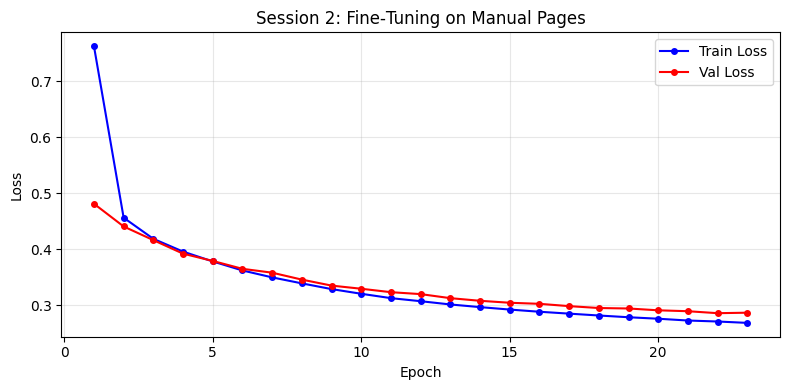

════════════════════════════════════════════════════════════
SESSION 2 COMPLETE — All artifacts saved
════════════════════════════════════════════════════════════
  DBNet checkpoint  : /kaggle/working/phase4/dbnet_ckpt/dbnet_manual_best.pt
  Artifacts JSON    : /kaggle/working/phase4/session2_artifacts.json
  Detection F1      : 0.9405
  Precision / Recall: 0.9148 / 0.9677
  Best val loss     : 0.2855

Session 3 will load this bundle and run TrOCR fine‑tuning & evaluation.


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9: Save All Artifacts for Session 3 (TrOCR)
# ══════════════════════════════════════════════════════════════════════════════

# ── Plot training curves ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss', markersize=4)
ax.plot(range(1, len(val_losses)+1),   val_losses,   'r-o', label='Val Loss',   markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Session 2: Fine‑Tuning on Manual Pages')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "session2_loss_curves.png", dpi=120)
plt.show()

# ── Save detection metrics ─────────────────────────────────────────────────
det_metrics_file = RESULTS_DIR / "detection_metrics.json"
with open(det_metrics_file, "w") as f:
    json.dump(det_metrics, f, indent=2)

# ── Count files in manual directories ──────────────────────────────────────
def count_image_files(directory):
    return len([f for f in Path(directory).iterdir() if f.is_file()])

manual_train_img_count = count_image_files(MANUAL_TRAIN / "images")
manual_val_img_count   = count_image_files(MANUAL_VAL   / "images")

# ── Save complete artifact bundle ──────────────────────────────────────────
session2_artifacts = {
    # ── Vocabulary (must match Phase 3.5 TrOCR) ──────────────────────────
    "char_to_token": char_to_token,
    "token_to_char": {str(k): v for k, v in token_to_char.items()},
    "actual_chars": actual_chars,
    "VOCAB_SIZE": VOCAB_SIZE,
    "PAD_ID": PAD_ID,
    "BOS_ID": BOS_ID,
    "EOS_ID": EOS_ID,
    "UNK_ID": UNK_ID,

    # ── DBNet detection config ──────────────────────────────────────────
    "best_det_ckpt": str(BEST_DET_CKPT),
    "det_metrics": det_metrics,
    "bin_thresh": best_bin,          # from the sweep
    "box_thresh": best_box,
    "merge_gap": best_gap,
    "img_size": DET_IMG_SIZE,
    "min_word_h": MIN_WORD_H,
    "min_word_w": MIN_WORD_W,
    "iou_merge_thresh": IOU_MERGE_THRESH,
    "crop_pad": CROP_PAD,

    # ── TrOCR / LoRA config ──────────────────────────────────────────────
    "trocr_size": TROCR_SIZE,
    "max_len": MAX_LEN,
    "no_repeat_ngram": NO_REPEAT_NGRAM,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "lora_target": LORA_TARGET,

    # ── Needleman‑Wunsch config ─────────────────────────────────────────
    "max_edit_ratio": MAX_EDIT_RATIO,
    "nw_gap": NW_GAP,
    "nw_match": NW_MATCH,
    "nw_mismatch": NW_MISMATCH,

    # ── TrOCR fine‑tuning hyperparams ────────────────────────────────────
    "ft_epochs": FT_EPOCHS,
    "ft_bs": FT_BS,
    "ft_lr": FT_LR,
    "ft_wd": FT_WD,
    "ft_grad_clip": FT_GRAD_CLIP,
    "ft_patience": FT_PATIENCE,

    # ── Dataset info (FIXED counts) ──────────────────────────────────────
    "manual_train_pages": manual_train_img_count,
    "manual_val_pages": manual_val_img_count,
    "manual_boxes_train": sum(len(v['polygons']) for v in train_labels.values()),
    "manual_boxes_val": sum(len(v['polygons']) for v in val_labels.values()),

    # ── Training log ────────────────────────────────────────────────────
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss": best_val_loss,
}

artifact_path = OUTPUT_DIR / "session2_artifacts.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(session2_artifacts, f, ensure_ascii=False, indent=2)

print("═" * 60)
print("SESSION 2 COMPLETE — All artifacts saved")
print("═" * 60)
print(f"  DBNet checkpoint  : {BEST_DET_CKPT}")
print(f"  Artifacts JSON    : {artifact_path}")
print(f"  Detection F1      : {det_metrics['f1']:.4f}")
print(f"  Precision / Recall: {det_metrics['precision']:.4f} / {det_metrics['recall']:.4f}")
print(f"  Best val loss     : {best_val_loss:.4f}")
print(f"\nSession 3 will load this bundle and run TrOCR fine‑tuning & evaluation.")